In [2]:
def luythua(x,n):
    return x**n
luythua(2,1),luythua(2,0)

(2, 1)

In [3]:
def frange(start, stop, step):
    x = start
    values = []
    while x <= stop:
        values.append(x)
        x += step
    return values

frange(0, 1, 0.2)


[0, 0.2, 0.4, 0.6000000000000001, 0.8, 1.0]

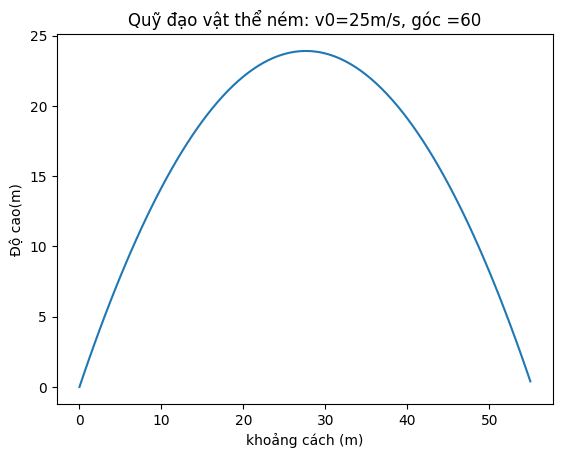

In [4]:
import math
import matplotlib.pyplot as plt
v0=25
theta_deg=60
g=9.8
theta=math.radians(theta_deg)
t_max = 2*v0*math.sin(theta)/g
t=0
dt=0.05
xs=[]
ys=[]
while t<=t_max:
    x=v0*math.cos(theta)*t
    y=v0*math.sin(theta)*t-0.5*g*t**2
    xs.append(x)
    ys.append(y)
    t+=dt
plt.plot(xs,ys)
plt.xlabel('khoảng cách (m)')
plt.ylabel('Độ cao(m)')
plt.title('Quỹ đạo vật thể ném: v0=25m/s, góc =60')
plt.show()

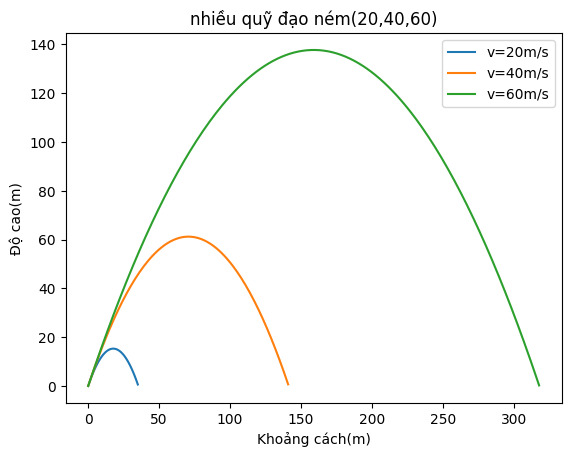

In [5]:
import math
import matplotlib.pyplot as plt
g=9.8
theta_deg=60
theta=math.radians(theta_deg)
def frange(start,stop,step):
    x= start
    values = []
    while x <= stop:
        values.append(x)
        x += step
    return values
def trajectory(v):
    t_max=2*v*math.sin(theta)/g
    ts=frange(0,t_max,0.05)
    xs=[v*math.cos(theta)*t for t in ts]
    ys=[v*math.sin(theta)*t-0.5*g*t**2 for t in ts]
    return xs,ys
def main():
    for v in[20,40,60]:
        xs, ys=trajectory(v)
        plt.plot(xs,ys,label=f"v={v}m/s")
    plt.xlabel('Khoảng cách(m)')
    plt.ylabel('Độ cao(m)')
    plt.title('nhiều quỹ đạo ném(20,40,60)')
    plt.legend()
    plt.show()
main()
    

In [6]:
from sympy import symbols, sympify, Limit
x=symbols('x')
def dao_ham(expr,var):
    f=sympify(expr)
    h=symbols('h')
    return Limit((f.subs(var,var+h)-f)/h,h,0).doit()
dao_ham('x**3+x**2+x',x)


3*x**2 + 2*x + 1

In [7]:
dao_ham('sin(x**2)',x)

2*x*cos(x**2)

In [8]:
from sympy import symbols, sympify, Limit
x=symbols('x')
def dao_ham(expr,var):
    f=sympify(expr)
    h=symbols('h')
    return Limit((f.subs(var,var+h)-f)/h,h,0).doit()
dao_ham('x**3+x**2+x',x)


3*x**2 + 2*x + 1

In [9]:
import math

def range_projectile(v, theta_deg, g=9.8):
    return v**2 * math.sin(math.radians(2*theta_deg)) / g

def grad_range(v, theta_deg, g=9.8):
    return (2*v**2/g) * math.cos(math.radians(2*theta_deg))

theta = 10
lr = 0.1

for _ in range(50):
    theta += lr * grad_range(20, theta)

theta, range_projectile(20, theta)


(44.99999773639459, 40.816326530612116)

In [10]:
from sympy import symbols, sympify,Limit,solve
x=symbols('x')
expr=sympify('x**3-6*x**2+9*x+15')
h=symbols('h')
dC=Limit((expr.subs(x,x+h)-expr)/h,h,0).doit()
dC

3*x**2 - 12*x + 9

In [11]:
solve(dC,x)

[1, 3]

In [12]:
[expr.subs(x,val) for val in solve(dC,x)]

[19, 15]

In [13]:
import math 
v=20
g=9.8
def R(theta):
    return v**2*math.sin(math.radians(2*theta))/g
angles=[10,20,30,40,45,60]
[(a,R(a)) for a in angles]

[(10, 13.960005850027292),
 (20, 26.23622896679752),
 (30, 35.34797566467096),
 (40, 40.19623481682481),
 (45, 40.816326530612244),
 (60, 35.34797566467097)]

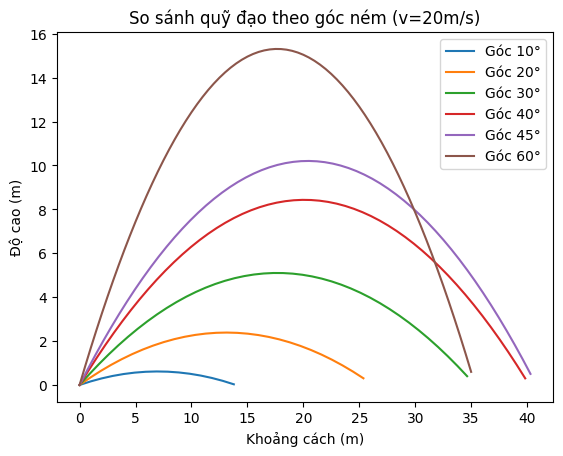

In [14]:
import math
import matplotlib.pyplot as plt

v0 = 20
g = 9.8

def frange(start, stop, step):
    x = start
    values = []
    while x <= stop:
        values.append(x)
        x += step
    return values

def trajectory(theta_deg):
    theta = math.radians(theta_deg)
    t_max = 2*v0*math.sin(theta)/g
    ts = frange(0, t_max, 0.05)
    xs = [v0*math.cos(theta)*t for t in ts]
    ys = [v0*math.sin(theta)*t - 0.5*g*t*t for t in ts]
    return xs, ys

def main():
    angles = [10,20,30,40,45,60]
    for ang in angles:
        xs, ys = trajectory(ang)
        plt.plot(xs, ys, label=f"Góc {ang}°")
    plt.xlabel("Khoảng cách (m)")
    plt.ylabel("Độ cao (m)")
    plt.title("So sánh quỹ đạo theo góc ném (v=20m/s)")
    plt.legend()
    plt.show()

main()




In [15]:
best_theta=max(range(1,90),key=lambda t:R(t))
best_theta,R(best_theta)

(45, 40.816326530612244)

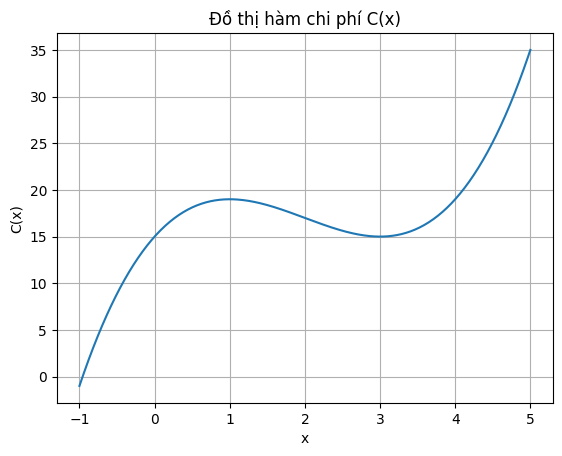

In [16]:
from sympy import symbols, sympify, lambdify
import matplotlib.pyplot as plt
import numpy as np

x = symbols('x')
expr = sympify('x**3 - 6*x**2 + 9*x + 15')

f = lambdify(x, expr, 'numpy')

xs = np.linspace(-1, 5, 400)
ys = f(xs)

plt.plot(xs, ys)
plt.xlabel("x")
plt.ylabel("C(x)")
plt.title("Đồ thị hàm chi phí C(x)")
plt.grid(True)
plt.show()
